In [4]:
!pip install -q transformers accelerate pillow matplotlib

In [5]:
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from transformers import AutoImageProcessor, YolosForObjectDetection
from google.colab import files

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device being used:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled.")
    print("Go to Runtime → Change runtime type → T4 GPU")

Device being used: cpu
GPU is not enabled.
Go to Runtime → Change runtime type → T4 GPU


In [7]:
MODEL_NAME = "hustvl/yolos-tiny"

print("Loading image processor...")

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

print("Loading YOLOS model...")

model = YolosForObjectDetection.from_pretrained(
    MODEL_NAME
)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

Loading image processor...


preprocessor_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

Loading YOLOS model...


config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 26.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model loaded successfully.


In [8]:
uploaded_files = files.upload()

Saving three-penguins.jpg to three-penguins.jpg


Uploaded image: three-penguins.jpg
Image size: (612, 408)


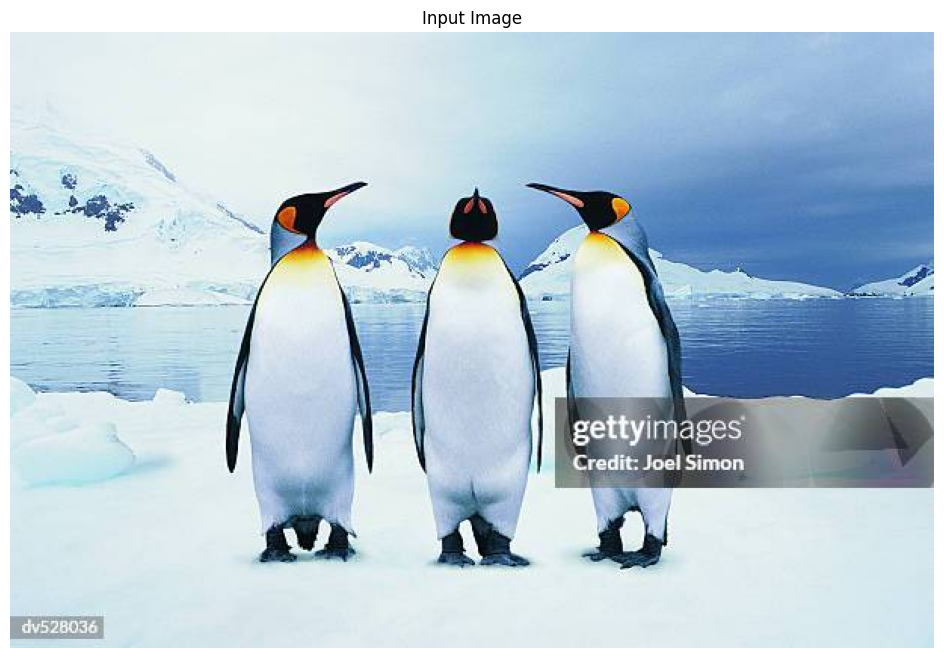

In [9]:
uploaded_filename = next(iter(uploaded_files))

image = Image.open(uploaded_filename).convert("RGB")

print("Uploaded image:", uploaded_filename)
print("Image size:", image.size)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [10]:
CONFIDENCE_THRESHOLD = 0.70

inputs = image_processor(
    images=image,
    return_tensors="pt"
)

inputs = {
    name: tensor.to(device)
    for name, tensor in inputs.items()
}

with torch.inference_mode():
    outputs = model(**inputs)

target_sizes = torch.tensor(
    [[image.height, image.width]],
    device=device
)

results = image_processor.post_process_object_detection(
    outputs,
    threshold=CONFIDENCE_THRESHOLD,
    target_sizes=target_sizes
)[0]

print("Object detection completed.")

Object detection completed.


In [11]:
detections = []

for score, label_id, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):
    label_name = model.config.id2label[
        int(label_id.item())
    ]

    confidence = float(score.item())

    bounding_box = [
        round(value, 2)
        for value in box.tolist()
    ]

    detections.append(
        {
            "label": label_name,
            "confidence": confidence,
            "box": bounding_box
        }
    )

if len(detections) == 0:
    print(
        "No objects were detected above the confidence threshold."
    )
else:
    print("Number of detected objects:", len(detections))
    print("-" * 80)

    for number, detection in enumerate(
        detections,
        start=1
    ):
        print(
            f"{number}. "
            f"Object: {detection['label']}, "
            f"Confidence: "
            f"{detection['confidence']:.2%}, "
            f"Box: {detection['box']}"
        )

Number of detected objects: 3
--------------------------------------------------------------------------------
1. Object: bird, Confidence: 99.05%, Box: [144.49, 99.07, 244.64, 353.8]
2. Object: bird, Confidence: 98.07%, Box: [333.14, 98.8, 448.52, 356.97]
3. Object: bird, Confidence: 84.15%, Box: [263.75, 104.03, 357.24, 357.07]


In [12]:
annotated_image = image.copy()

draw = ImageDraw.Draw(annotated_image)

try:
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        18
    )
except OSError:
    font = ImageFont.load_default()

box_line_width = max(
    2,
    round(min(image.size) / 250)
)

for detection in detections:
    label = detection["label"]
    confidence = detection["confidence"]

    x_min, y_min, x_max, y_max = detection["box"]

    label_text = f"{label}: {confidence:.1%}"

    # Draw object bounding box
    draw.rectangle(
        [(x_min, y_min), (x_max, y_max)],
        outline="red",
        width=box_line_width
    )

    # Calculate text dimensions
    text_box = draw.textbbox(
        (0, 0),
        label_text,
        font=font
    )

    text_width = text_box[2] - text_box[0]
    text_height = text_box[3] - text_box[1]

    text_x = max(0, int(x_min))
    text_y = max(
        0,
        int(y_min) - text_height - 10
    )

    # Draw label background
    draw.rectangle(
        [
            (text_x, text_y),
            (
                text_x + text_width + 10,
                text_y + text_height + 10
            )
        ],
        fill="red"
    )

    # Draw label text
    draw.text(
        (text_x + 5, text_y + 5),
        label_text,
        fill="white",
        font=font
    )

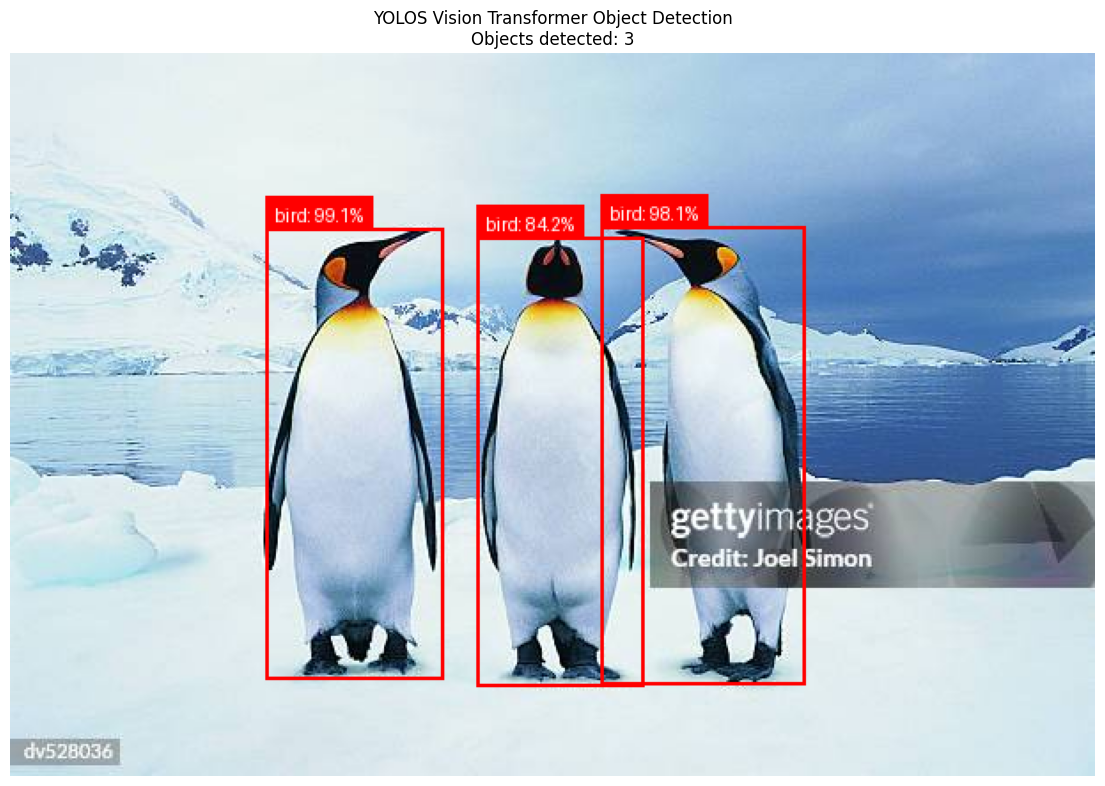

In [13]:
plt.figure(figsize=(14, 10))

plt.imshow(annotated_image)

plt.axis("off")

plt.title(
    f"YOLOS Vision Transformer Object Detection\n"
    f"Objects detected: {len(detections)}"
)

plt.show()

In [15]:
OUTPUT_FILENAME = "vision_transformer_detection.jpg"

annotated_image.save(
    OUTPUT_FILENAME,
    quality=95
)

print("Output image saved as:", OUTPUT_FILENAME)

Output image saved as: vision_transformer_detection.jpg


In [16]:
files.download(OUTPUT_FILENAME)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>